In [28]:
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import requests
import re
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from io import StringIO
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

In [29]:
# Year,Decade,Winner,Movie,IMDbRating,Runtime,Director,Actors,Writer(s),Distributor,Producer(s),Genre,BoxOffice

In [41]:
film_df = pd.read_csv("best_pic_nominees_winners.csv")

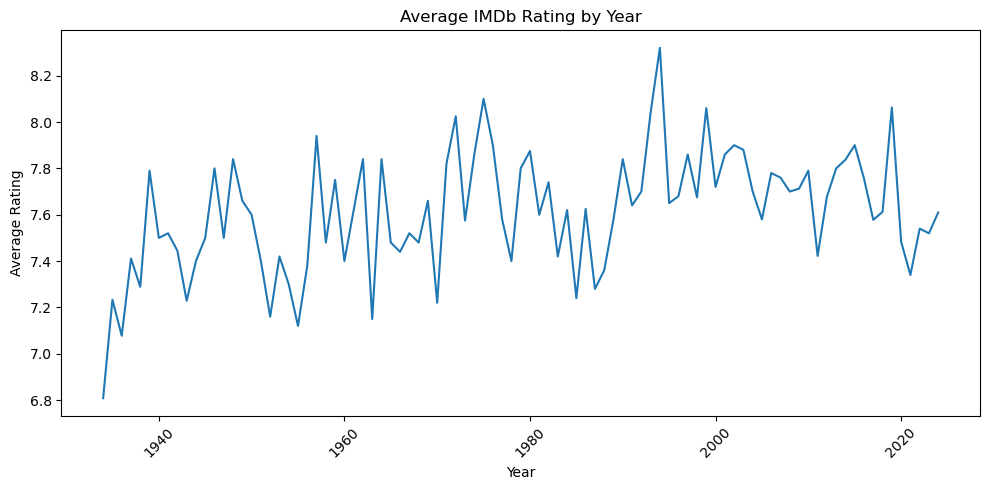

In [48]:
# By Year
rating_by_year = film_df.groupby("Year")["IMDbRating"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=rating_by_year)
plt.title("Average IMDb Rating by Year")
plt.ylabel("Average Rating")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


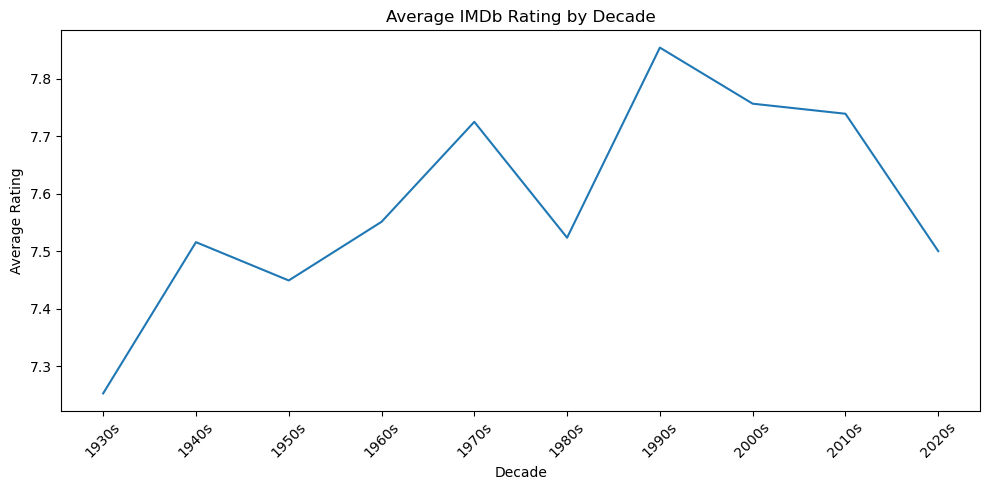

In [44]:
# By Decade
rating_by_decade = film_df.groupby("Decade")["IMDbRating"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=rating_by_decade)
plt.title("Average IMDb Rating by Decade")
plt.ylabel("Average Rating")
plt.xlabel("Decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

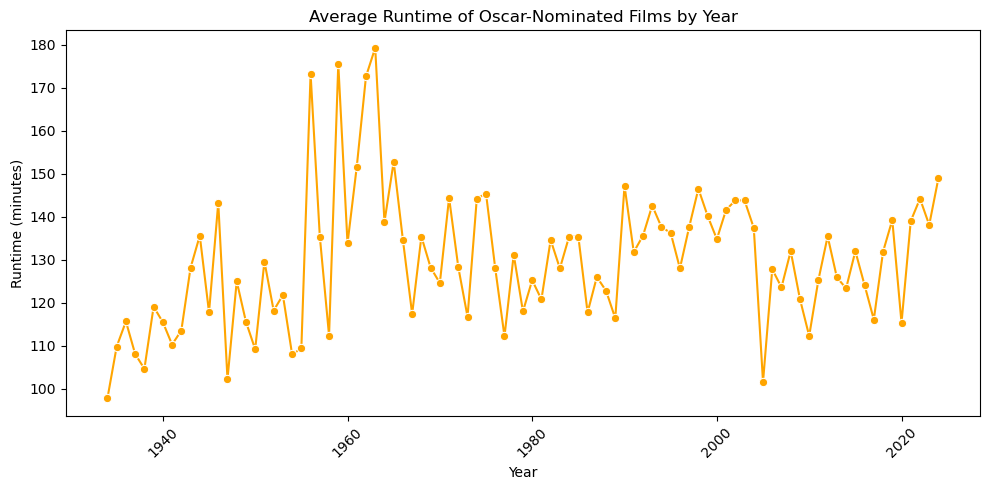

In [47]:
runtime_by_year = film_df.groupby("Year")["Runtime"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=runtime_by_year, marker="o", color="orange")
plt.title("Average Runtime of Oscar-Nominated Films by Year")
plt.ylabel("Runtime (minutes)")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

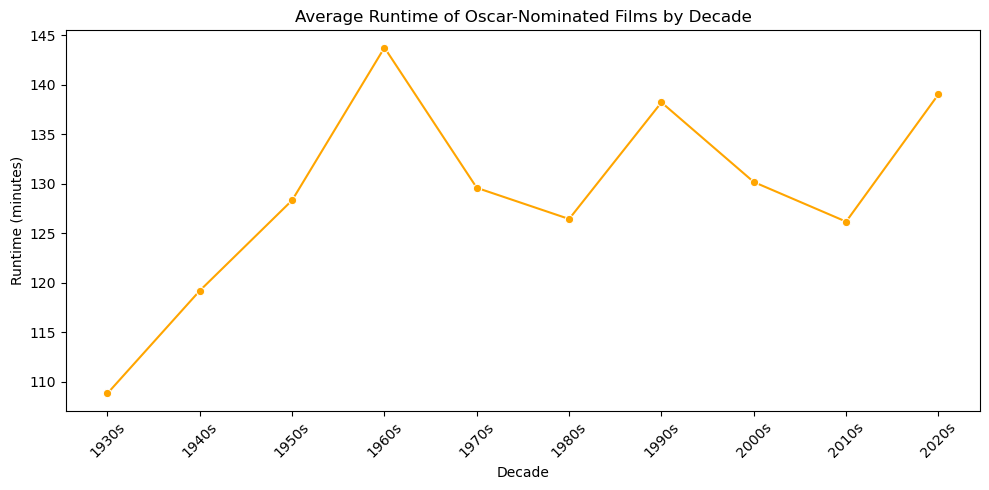

In [45]:
runtime_by_decade = film_df.groupby("Decade")["Runtime"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=runtime_by_decade, marker="o", color="orange")
plt.title("Average Runtime of Oscar-Nominated Films by Decade")
plt.ylabel("Runtime (minutes)")
plt.xlabel("Decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
def genre_counts(movies_df):
    exploded_genre = movies_df['Genre'].dropna().str.split(',').explode().str.strip()
    return exploded_genre.value_counts()


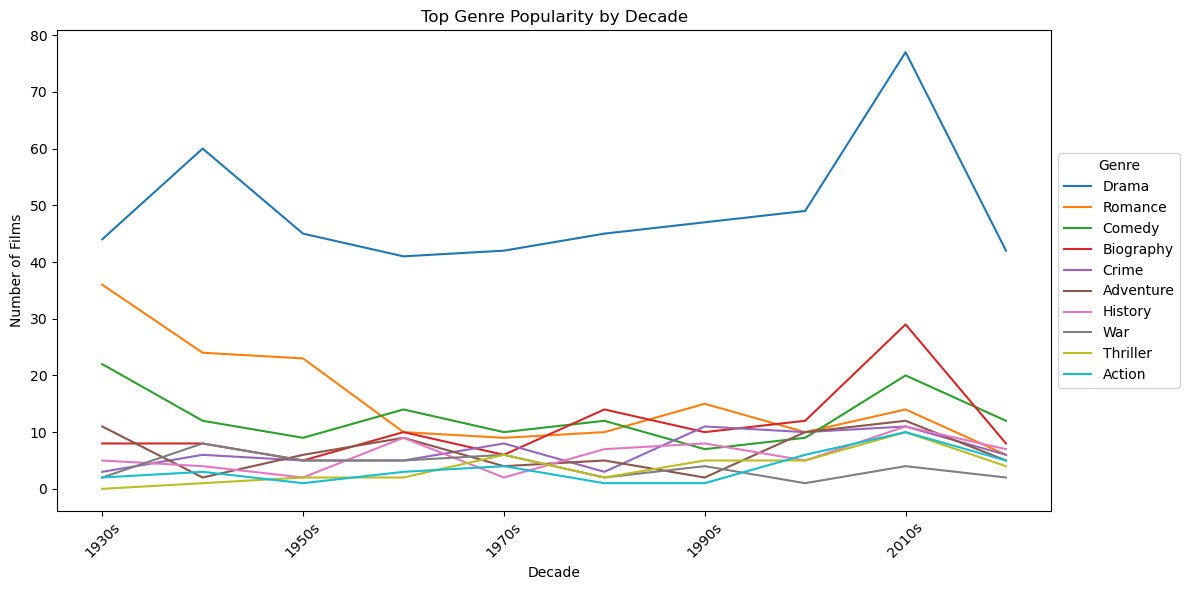

In [ ]:
top_genres = genre_counts(film_df).head(10).index.tolist()

genre_by_decade = {}

for decade, group in film_df.groupby("Decade"):
    exploded = group['Genre'].dropna().str.split(',').explode().str.strip()
    filtered = exploded[exploded.isin(top_genres)]
    genre_counts_decade = Counter(filtered)
    genre_by_decade[decade] = genre_counts_decade

genre_trend_df = pd.DataFrame(genre_by_decade).fillna(0).astype(int).T

genre_trend_df[top_genres].plot(kind="line", figsize=(12, 6))
plt.title("Top Genre Popularity by Decade")
plt.ylabel("Number of Films")
plt.xlabel("Decade")
plt.xticks(rotation=45)
plt.legend(title="Genre", loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [54]:
# separate into winners and nominees
winners_df = film_df[film_df['Winner'] == True]
nominees_df = film_df[film_df['Winner'] == False]

In [57]:
# comparison of genres
def genre_counts(film_df):
    # separate each genre into a row
    exploded_category = film_df['Genre'].str.split(',').explode().str.strip()
    return exploded_category.value_counts()

# count winners vs non-winners
genre_counts_winners = genre_counts(winners_df)
genre_counts_nominees = genre_counts(nominees_df)

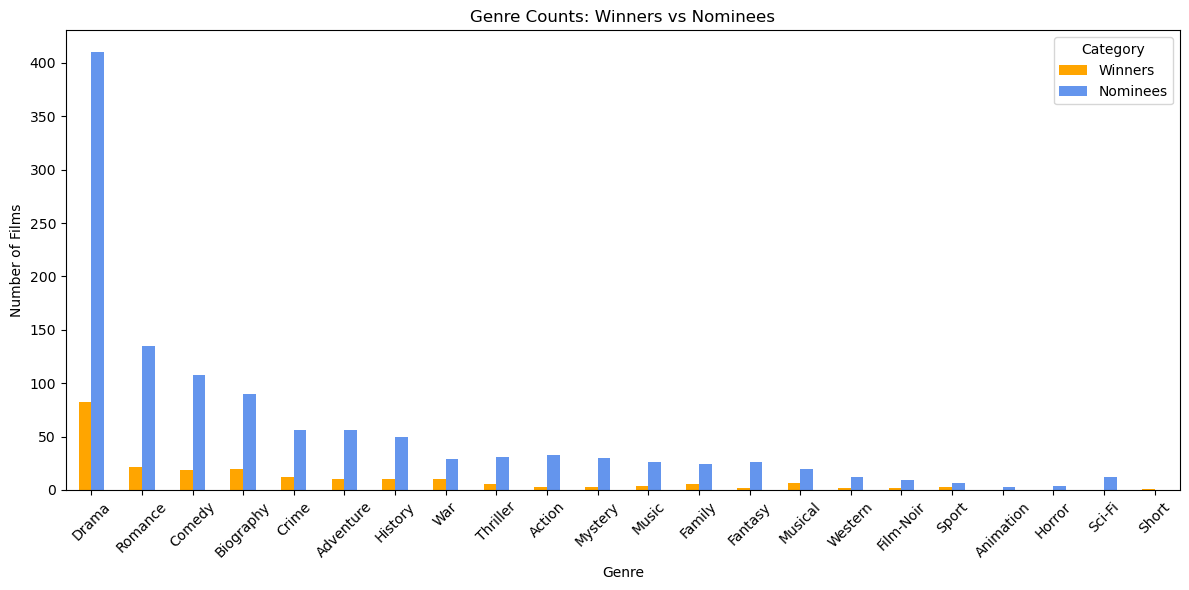

In [65]:
genre_df = pd.DataFrame ({
    'Winners': genre_counts_winners,
    'Nominees': genre_counts_nominees
})

genre_df['Total'] = genre_df['Winners'] + genre_df['Nominees']
genre_df = genre_df.sort_values(by='Total', ascending=False)
genre_df = genre_df.drop(columns='Total')

genre_df.plot(kind='bar', figsize=(12,6), color=['orange', 'cornflowerblue'])
plt.title("Genre Counts: Winners vs Nominees")
plt.ylabel("Number of Films")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

In [79]:
# comparison of directors
def director_counts(film_df):
    # separate each genre into a row
    exploded_category = film_df['Director'].str.split(',').explode().str.strip()
    return exploded_category.value_counts()

# count winners vs non-winners
director_winners = director_counts(winners_df)
director_nominees = director_counts(nominees_df)

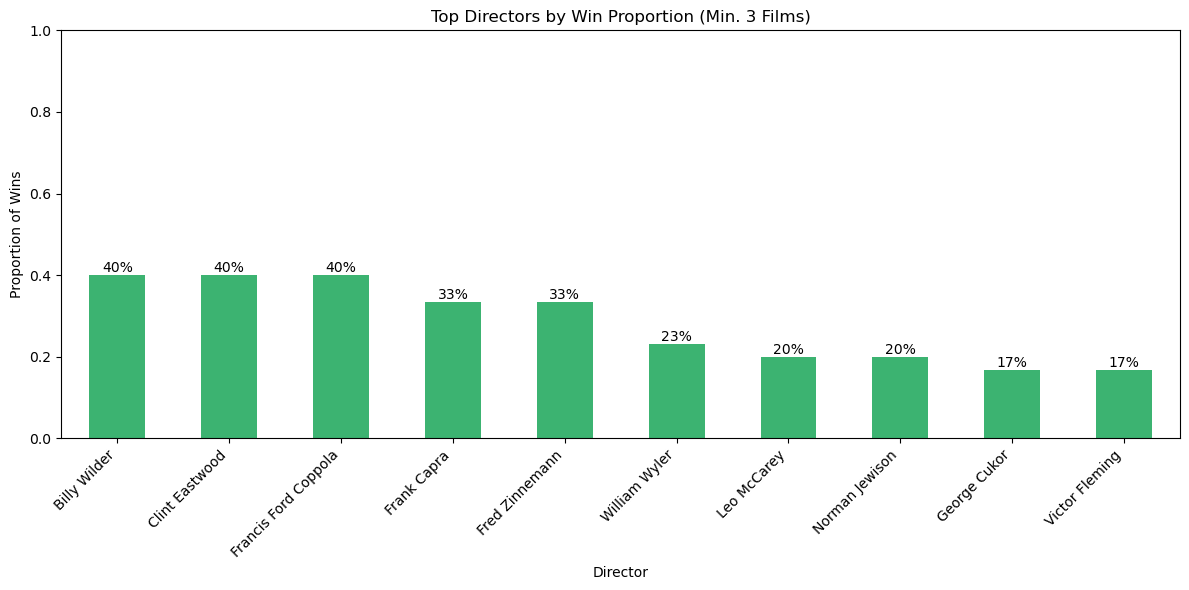

In [80]:
director_df = pd.DataFrame({
    'Winners': director_winners,
    'Nominees': director_nominees
})

director_df['Total'] = director_df['Winners'] + director_df['Nominees']
director_df = director_df[director_df['Total'] >= 5]
director_df['Proportion'] = director_df['Winners'] / director_df['Total']

top_directors = director_df.sort_values(by='Proportion', ascending=False).head(10)

ax = top_directors['Proportion'].plot(
    kind='bar',
    figsize=(12, 6),
    color='mediumseagreen'
)

plt.title("Top Directors by Win Proportion (Min. 3 Films)")
plt.ylabel("Proportion of Wins")
plt.xlabel("Director")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()

for idx, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.annotate(f"{height:.0%}",
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()

In [81]:
# comparison of writers
def writer_counts(film_df):
    # separate each writer into a row
    exploded_category = film_df['Writer(s)'].str.split(',').explode().str.strip()
    return exploded_category.value_counts()

# count winners vs non-winners
writer_winners = writer_counts(winners_df)
writer_nominees = writer_counts(nominees_df)

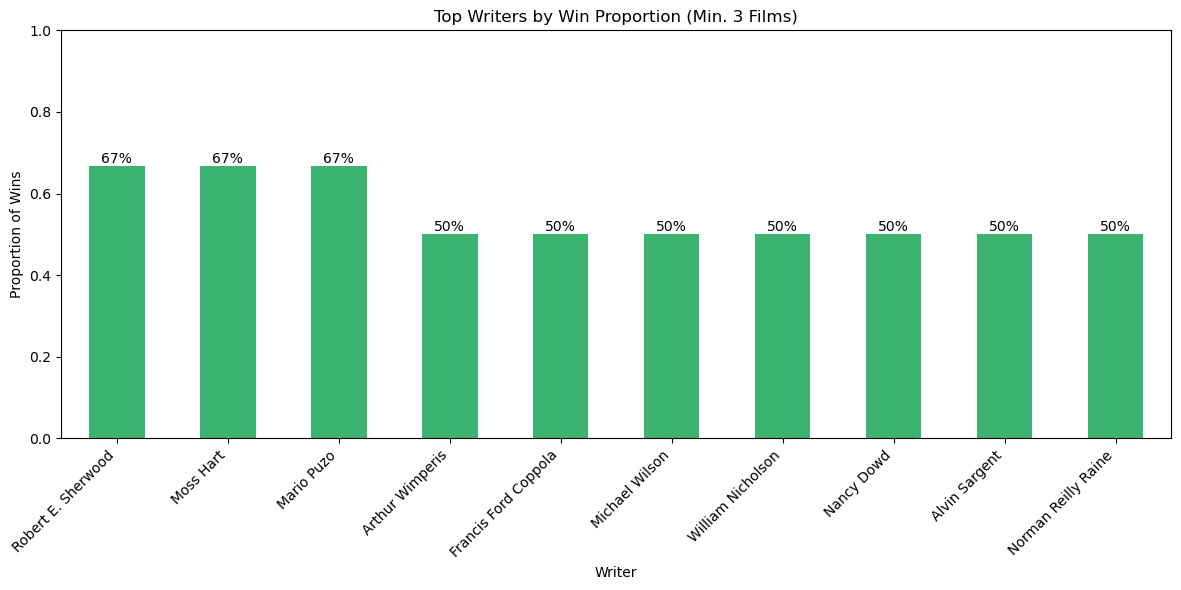

In [82]:
writer_df = pd.DataFrame({
    'Winners': writer_winners,
    'Nominees': writer_nominees
})

writer_df['Total'] = writer_df['Winners'] + writer_df['Nominees']
writer_winners_df = writer_df[writer_df['Total'] >= 5]
writer_df['Proportion'] = writer_df['Winners'] / writer_df['Total']

top_writers = writer_df.sort_values(by='Proportion', ascending=False).head(10)

ax = top_writers['Proportion'].plot(
    kind='bar',
    figsize=(12, 6),
    color='mediumseagreen'
)

plt.title("Top Writers by Win Proportion (Min. 3 Films)")
plt.ylabel("Proportion of Wins")
plt.xlabel("Writer")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()

for idx, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.annotate(f"{height:.0%}",
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()